
#  Spatial Transcriptomics Trajectory Analysis (DLPFC)

 This script performs:
1. Load DLPFC spatial transcriptomics data
2. Preprocess and select highly variable genes
3. Construct spatial graph using AlphaComplex
4. Train StPedf model to obtain low-dimensional embedding
5. Build protected adaptive transition matrix
6. Infer pseudotime from WM layer
7. Compute vector field velocity
8. Visualize pseudotime and trajectory

In [3]:
import warnings
warnings.filterwarnings("ignore")

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
import ot

import StPedf
import TI as spt
from TI.single_time import construct_protected_adaptive_transition_matrix

# %%
# Set random seed
random_seed = 2023
StPedf.fix_seed(random_seed)

# GPU device
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# Paths and sample
data_root = Path(r'F:\StPedf\data\DLPFC')
sample_name = '151673'
n_clusters = 5 if sample_name in ['151669', '151670', '151671', '151672'] else 7


# 1. Load and preprocess DLPFC data

In [4]:
# %%
adata = sc.read_visium(data_root / sample_name)
adata.var_names_make_unique()

# Add layer annotation
df_meta = pd.read_csv(data_root / sample_name / 'metadata.tsv', sep='\t')
adata.obs['layer_guess'] = df_meta['layer_guess']

# Preprocessing
adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=20)
sc.pp.filter_genes(adata, min_counts=5)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)

adata = adata[:, adata.var['highly_variable']]
sc.pp.scale(adata)

# PCA (using sklearn for stability)
from sklearn.decomposition import PCA
adata.obsm['X_pca'] = PCA(n_components=200, random_state=42).fit_transform(adata.X)

#  2. Visualize spatial layers

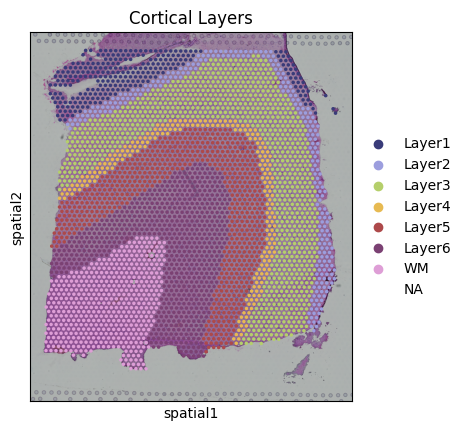

In [5]:
sc.pl.spatial(adata, color="layer_guess", title="Cortical Layers",
              legend_loc="right margin", palette="tab20b", size=1)


# 3. Construct spatial graph (AlphaComplex)

In [6]:
graph_dict = StPedf.graph_construction(adata, mode='AlphaComplex', alpha_n_neighbors=20)
print("Graph keys:", list(graph_dict.keys()))

Graph keys: ['adj_norm', 'adj_label', 'norm_value']


# 4. Train StPedf model

In [7]:
StPedf_net = StPedf.StPedf(adata.obsm['X_pca'], graph_dict, mode='clustering', device=device)
StPedf_net.train_with_dec(N=100)  # train with deep embedding clustering
StPedf_feat, _, _, _, _ = StPedf_net.process()
adata.obsm['StPedf'] = StPedf_feat

100%|██████████| 200/200 [00:02<00:00, 69.08it/s]


#  5. Build protected adaptive transition matrix

In [8]:
trans = construct_protected_adaptive_transition_matrix(
    adata,
    StPedf_key='StPedf',
    spatial_key='spatial',
    reg=0.005,
    alpha_range=(0.4, 0.6),
    protected_alpha=0.4,
    density_bandwidth=50.0,
    reliability_k=20,
    reliability_threshold=0.35,
    edge_quantile=0.03,
    hole_neighbor_quantile=0.90,
    spot_size=50
)
adata.obsp["adaptive_trans"] = trans
adata.obsp["trans"] = trans  # rename for compatibility
print("Transition matrix shape:", trans.shape)

========== Protected adaptive transition summary ==========
alpha_range = (0.4, 0.6)
protected_alpha = 0.4
edge count = 430 / 3639
hole-like count = 409 / 3639
low-reliability count = 18 / 3639
low-confidence count = 556 / 3639
Transition matrix shape: (3639, 3639)



# 6. Pseudotime inference from WM layer

Number of start cells: 513


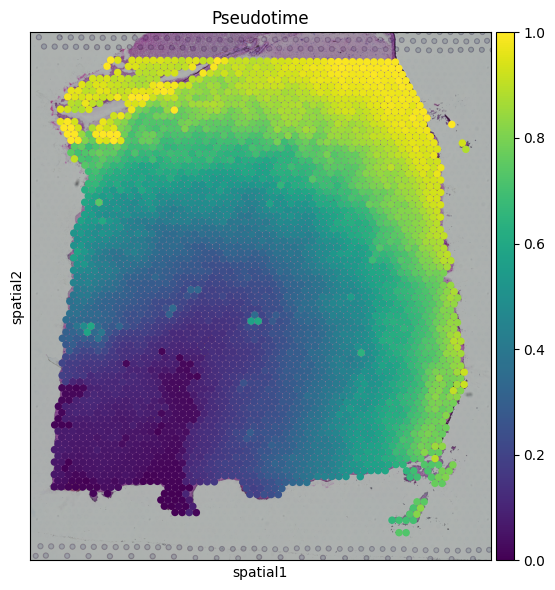

In [9]:
# Set cluster annotation
adata.obs['cluster'] = adata.obs['layer_guess'].astype('category')

# Select start cells (WM layer)
start_cells = spt.set_start_cells(
    adata,
    select_way='cell_type',
    cell_type='WM',
    n_neigh=30,
    basis='spatial'
)
print(f"Number of start cells: {len(start_cells)}")

# Compute pseudotime
adata.obs["ptime"] = spt.get_ptime(adata, start_cells=start_cells)

# Visualize pseudotime
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.spatial(adata, color='ptime', title='Pseudotime', size=1.5, ax=ax, show=False)
plt.tight_layout()
plt.show()


# 7. Compute vector field velocity

In [10]:
# Ensure spatial coordinates are available
adata.obsm['X_spatial'] = adata.obsm['spatial']

# Compute velocity grid
adata.uns["E_grid"], adata.uns["V_grid"] = spt.get_velocity(adata, basis="spatial", n_neigh_pos=50)

# Build vector field
VecFld = spt.VectorField(
    adata,
    basis='spatial',
    velocity_key='velocity_spatial',
    n_neighbors=80,
    smooth=1.5
)

Cell velocities stored in 'velocity_spatial'



#  8. Visualize trajectory with streamlines

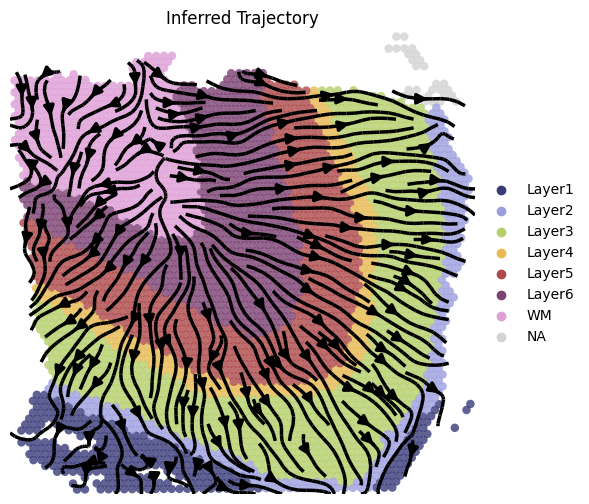

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.embedding(adata, basis='spatial', color='cluster', show=False, ax=ax,
                frameon=False, palette='tab20b', alpha=0.8, size=150)
ax.streamplot(adata.uns['E_grid'][0], adata.uns['E_grid'][1],
              adata.uns['V_grid'][0], adata.uns['V_grid'][1],
              density=1.8, color='black', linewidth=2.5, arrowsize=1.5)
plt.title("Inferred Trajectory")
plt.show()